In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df_lic = pd.read_parquet("data/data_licences/data_licences.parquet")
df_med = pd.read_csv("data/data_medailles/data_medailles_jo.csv")
df_or = pd.read_csv("data/data_medailles/data_or_jo.csv")
df_argent = pd.read_csv("data/data_medailles/data_argent_jo.csv")
df_bronze = pd.read_csv("data/data_medailles/data_bronze_jo.csv")

In [4]:
print(df_med.columns)
df_lic.head()

Index(['code_sport', 'sport', '2024_or', '2020_or', '2016_or', '2024_argent',
       '2020_argent', '2016_argent', '2024_bronze', '2020_bronze',
       '2016_bronze', 'total_medailles_2016', 'total_medailles_2020',
       'total_medailles_2024'],
      dtype='object')


,code_2024,code_annee_n,codes_2016_2024,federation,annee,sexe,age,tranche_age,grande_tranche_age,region,departement_long,licences_annuelles,code_sport,code_dep
0,101,101,101,Fédération Française d'Athlétisme,2016,F,5,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,1,ATH,01
1,101,101,101,Fédération Française d'Athlétisme,2016,F,6,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,13,ATH,01
2,101,101,101,Fédération Française d'Athlétisme,2016,F,7,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,28,ATH,01
3,101,101,101,Fédération Française d'Athlétisme,2016,F,8,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,49,ATH,01
4,101,101,101,Fédération Française d'Athlétisme,2016,F,9,b - de 5 à 9 ans,1 - Enfants (1-13),84 - Auvergne-Rhône-Alpes,01 - Ain,76,ATH,01


In [3]:
# Copie de sécurité
df_lic_agg = df_lic.copy()

# Renommage pour clarté
df_lic_agg = df_lic_agg.rename(columns={
    'licences_annuelles': 'nb_licencies'
})

# AGRÉGATION : somme sur toutes les dimensions fines
df_lic_agg = (
    df_lic_agg
    .groupby(['code_sport', 'annee'], as_index=False)
    .agg({
        'nb_licencies': 'sum'
    })
)


In [4]:
def jo_reference(annee):
    if annee < 2020:
        return 2016
    elif annee < 2024:
        return 2020
    else:
        return 2024

df_lic_agg['jo'] = df_lic_agg['annee'].apply(jo_reference)

In [5]:
df_med_long = pd.concat([
    df_med[['code_sport', 'sport',
            '2016_or', '2016_argent', '2016_bronze', 'total_medailles_2016']]
        .rename(columns=lambda x: x.replace('2016_', ''))
        .assign(jo=2016),

    df_med[['code_sport', 'sport',
            '2020_or', '2020_argent', '2020_bronze', 'total_medailles_2020']]
        .rename(columns=lambda x: x.replace('2020_', ''))
        .assign(jo=2020),

    df_med[['code_sport', 'sport',
            '2024_or', '2024_argent', '2024_bronze', 'total_medailles_2024']]
        .rename(columns=lambda x: x.replace('2024_', ''))
        .assign(jo=2024),
], ignore_index=True)


In [7]:


# =========================
# 0) Helpers
# =========================
def jo_reference(annee: int) -> int:
    # Hypothèse "licences de l'année N = saison à partir de sept N (post JO été N)"
    if annee < 2020:
        return 2016
    elif annee < 2024:
        return 2020
    else:
        return 2024


def safe_div(a, b):   # permet de gerer le cas où on a un nombre de licencié nul ce qui évite des métriques divergentes (dans ce cas on pose = 0)
    return np.where(b == 0, 0.0, a / b)


# =========================
# 1) Build medals long table
# =========================
def build_med_long(df_med: pd.DataFrame) -> pd.DataFrame:
    # 2016
    m2016 = df_med[['code_sport', 'sport', '2016_or', '2016_argent', '2016_bronze', 'total_medailles_2016']].copy()
    m2016 = m2016.rename(columns={
        '2016_or': 'or', '2016_argent': 'argent', '2016_bronze': 'bronze', 'total_medailles_2016': 'total_medailles'
    })
    m2016['jo'] = 2016

    # 2020
    m2020 = df_med[['code_sport', 'sport', '2020_or', '2020_argent', '2020_bronze', 'total_medailles_2020']].copy()
    m2020 = m2020.rename(columns={
        '2020_or': 'or', '2020_argent': 'argent', '2020_bronze': 'bronze', 'total_medailles_2020': 'total_medailles'
    })
    m2020['jo'] = 2020

    # 2024
    m2024 = df_med[['code_sport', 'sport', '2024_or', '2024_argent', '2024_bronze', 'total_medailles_2024']].copy()
    m2024 = m2024.rename(columns={
        '2024_or': 'or', '2024_argent': 'argent', '2024_bronze': 'bronze', 'total_medailles_2024': 'total_medailles'
    })
    m2024['jo'] = 2024

    med_long = pd.concat([m2016, m2020, m2024], ignore_index=True)
    return med_long


# =========================
# 2) Build sport-year features from micro licences
# =========================
def build_lic_features(df_lic: pd.DataFrame) -> pd.DataFrame:
    df = df_lic.copy()

    # --- sanity: ensure expected columns exist
    required = ['code_sport', 'annee', 'licences_annuelles']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes dans df_lic: {missing}")

    # Standardize types
    df['annee'] = df['annee'].astype(int)
    df['licences_annuelles'] = pd.to_numeric(df['licences_annuelles'], errors='coerce').fillna(0.0)

    # Optional columns: handle if absent
    if 'sexe' not in df.columns:
        df['sexe'] = 'U'
    if 'age' not in df.columns:
        df['age'] = np.nan
    if 'grande_tranche_age' not in df.columns:
        df['grande_tranche_age'] = 'Unknown'
    if 'code_dep' not in df.columns:
        df['code_dep'] = '00'

    # --- basic flags
    df['is_femme'] = (df['sexe'] == 'F').astype(int)
    df['is_homme'] = (df['sexe'] == 'H').astype(int)

    # age buckets (tu peux ajuster si besoin)
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['is_jeune_lt14'] = ((df['age'] < 14) & df['age'].notna()).astype(int)
    df['is_jeune_14_17'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)
    df['is_adulte_18_34'] = ((df['age'] >= 18) & (df['age'] <= 34)).astype(int)
    df['is_adulte_35_49'] = ((df['age'] >= 35) & (df['age'] <= 49)).astype(int)
    df['is_senior_50p'] = ((df['age'] >= 50)).astype(int)

    # --- aggregate totals per sport-year
    g = df.groupby(['code_sport', 'annee'], as_index=False)

    # Total licences
    base = g.agg(nb_licencies=('licences_annuelles', 'sum'))

    # Sex shares
    sex = g.apply(lambda x: pd.Series({
        'nb_femmes': (x['licences_annuelles'] * x['is_femme']).sum(),
        'nb_hommes': (x['licences_annuelles'] * x['is_homme']).sum()
    })).reset_index()

  

    # Age weighted stats + shares (robuste)
    def _age_block(x):
        w = x['licences_annuelles'].to_numpy(dtype=float)
        a = x['age'].to_numpy(dtype=float)

        mask = ~np.isnan(a)
        w2 = w[mask]
        a2 = a[mask]

        if w2.sum() == 0:
            age_mean = np.nan
            age_std = np.nan
        else:
            age_mean = float((a2 * w2).sum() / w2.sum())
            age2_mean = float(((a2 ** 2) * w2).sum() / w2.sum())
            var = max(0.0, age2_mean - age_mean ** 2)
            age_std = float(np.sqrt(var))

        nb_lt14  = float((x.loc[x['is_jeune_lt14'] == 1, 'licences_annuelles']).sum())
        nb_14_17 = float((x.loc[x['is_jeune_14_17'] == 1, 'licences_annuelles']).sum())
        nb_18_34 = float((x.loc[x['is_adulte_18_34'] == 1, 'licences_annuelles']).sum())
        nb_35_49 = float((x.loc[x['is_adulte_35_49'] == 1, 'licences_annuelles']).sum())
        nb_50p   = float((x.loc[x['is_senior_50p'] == 1, 'licences_annuelles']).sum())

        return pd.Series({
            'age_mean': age_mean,
            'age_std': age_std,
            'nb_lt14': nb_lt14,
            'nb_14_17': nb_14_17,
            'nb_18_34': nb_18_34,
            'nb_35_49': nb_35_49,
            'nb_50p': nb_50p
        })

    age_stats = df.groupby(['code_sport', 'annee']).apply(_age_block).reset_index()




    # --- Grande tranche age distribution (wide)
    # sum licences by (sport, year, grande_tranche_age) then pivot
    tranche = (
        df.groupby(['code_sport', 'annee', 'grande_tranche_age'], as_index=False)
          .agg(tranche_lic=('licences_annuelles', 'sum'))
    )
    tranche_wide = tranche.pivot_table(
        index=['code_sport', 'annee'],
        columns='grande_tranche_age',
        values='tranche_lic',
        aggfunc='sum',
        fill_value=0.0
    ).reset_index()

    # rename tranche columns
    tranche_cols = [c for c in tranche_wide.columns if c not in ['code_sport', 'annee']]
    tranche_wide = tranche_wide.rename(columns={c: f"tranche_{str(c).strip().lower().replace(' ', '_')}" for c in tranche_cols})

    # --- Geography: number of active departments + concentration (Herfindahl)
    dept_sum = (
        df.groupby(['code_sport', 'annee', 'code_dep'], as_index=False)
          .agg(dep_lic=('licences_annuelles', 'sum'))
    )
    dept_feat = dept_sum.groupby(['code_sport', 'annee']).apply(lambda x: pd.Series({
        'nb_departements_actifs': (x['dep_lic'] > 0).sum(),
        # Herfindahl: sum of squared shares across departments (higher = more concentrated)
        'herfindahl_dep': (safe_div(x['dep_lic'].values, x['dep_lic'].sum()) ** 2).sum() if x['dep_lic'].sum() > 0 else 0.0
    })).reset_index()

    # --- Merge all feature blocks
    out = base.merge(sex, on=['code_sport', 'annee'], how='left') \
              .merge(age_stats, on=['code_sport', 'annee'], how='left') \
              .merge(tranche_wide, on=['code_sport', 'annee'], how='left') \
              .merge(dept_feat, on=['code_sport', 'annee'], how='left')

    # Shares from counts
    out['part_femmes'] = safe_div(out['nb_femmes'], out['nb_licencies'])
    out['part_hommes'] = safe_div(out['nb_hommes'], out['nb_licencies'])

    out['part_lt14'] = safe_div(out['nb_lt14'], out['nb_licencies'])
    out['part_14_17'] = safe_div(out['nb_14_17'], out['nb_licencies'])
    out['part_18_34'] = safe_div(out['nb_18_34'], out['nb_licencies'])
    out['part_35_49'] = safe_div(out['nb_35_49'], out['nb_licencies'])
    out['part_50p'] = safe_div(out['nb_50p'], out['nb_licencies'])

    # Drop intermediate absolute counts if you want (tu peux garder aussi)
    # out = out.drop(columns=['nb_femmes','nb_hommes','nb_lt14','nb_14_17','nb_18_34','nb_35_49','nb_50p'])

    # --- Lags and dynamics (NO leakage: only past years)
    out = out.sort_values(['code_sport', 'annee']).reset_index(drop=True)

    for lag in [1, 2]:
        out[f'nb_licencies_lag{lag}'] = out.groupby('code_sport')['nb_licencies'].shift(lag)
        out[f'part_femmes_lag{lag}'] = out.groupby('code_sport')['part_femmes'].shift(lag)
        out[f'age_mean_lag{lag}'] = out.groupby('code_sport')['age_mean'].shift(lag)

    out['croissance_lag1'] = safe_div(out['nb_licencies'] - out['nb_licencies_lag1'], out['nb_licencies_lag1'])
    out['croissance_lag2'] = safe_div(out['nb_licencies_lag1'] - out['nb_licencies_lag2'], out['nb_licencies_lag2'])

    # rolling mean of last 2 years (t-1,t-2) to predict t
    out['nb_licencies_roll2'] = (
        out.groupby('code_sport')['nb_licencies']
           .shift(1)
           .rolling(2)
           .mean()
           .reset_index(level=0, drop=True)
    )

    return out



In [8]:
def build_model_dataset(df_lic: pd.DataFrame, df_med: pd.DataFrame) -> tuple[pd.DataFrame, list, list]:
    # features from licences micro
    lic_feat = build_lic_features(df_lic)

    # medals long
    med_long = build_med_long(df_med)

    # attach JO reference to each sport-year observation
    lic_feat['jo'] = lic_feat['annee'].apply(jo_reference)
    lic_feat['annees_depuis_jo'] = lic_feat['annee'] - lic_feat['jo']

    # merge medals (sport, jo)
    df_model = lic_feat.merge(med_long, on=['code_sport', 'jo'], how='left')

    # categorical
    df_model['sport'] = df_model['sport'].astype('category')

    # optional target transforms
    df_model['log_nb_licencies'] = np.log1p(df_model['nb_licencies'])

    # choose features (tu peux en enlever/rajouter)
    tranche_feature_cols = [c for c in df_model.columns if c.startswith('tranche_')]
    features = [
        'sport', 'annee', 'annees_depuis_jo',
        'or', 'argent', 'bronze', 'total_medailles',
        'part_femmes', 'age_mean', 'age_std',
        'part_lt14', 'part_14_17', 'part_18_34', 'part_35_49', 'part_50p',
        'nb_departements_actifs', 'herfindahl_dep',
        'nb_licencies_lag1', 'nb_licencies_lag2', 'croissance_lag1', 'croissance_lag2', 'nb_licencies_roll2',
        'part_femmes_lag1', 'age_mean_lag1'
    ] + tranche_feature_cols

    # keep only columns that exist (robust)
    features = [c for c in features if c in df_model.columns]

    cat_features = ['sport']
    return df_model, features, cat_features


# =========================
# 4) RUN
# =========================
df_model, features, cat_features = build_model_dataset(df_lic, df_med)


In [9]:
df_effect = df_model.copy()

# On se limite aux années post JO 2020
df_effect = df_effect[(df_effect['annee'] >= 2021) & (df_effect['annee'] <= 2023)].copy()

# Cible : croissance annuelle
df_effect['growth'] = (
    (df_effect['nb_licencies'] - df_effect['nb_licencies_lag1'])
    / df_effect['nb_licencies_lag1']
)

# Nettoyage
df_effect = df_effect.replace([np.inf, -np.inf], np.nan)
df_effect = df_effect.dropna(subset=['growth'])
df_effect = df_model.copy()

# On se limite aux années post JO 2020
df_effect = df_effect[(df_effect['annee'] >= 2021) & (df_effect['annee'] <= 2023)].copy()

# Cible : croissance annuelle
df_effect['growth'] = (
    (df_effect['nb_licencies'] - df_effect['nb_licencies_lag1'])
    / df_effect['nb_licencies_lag1']
)

# Nettoyage
df_effect = df_effect.replace([np.inf, -np.inf], np.nan)
df_effect = df_effect.dropna(subset=['growth'])


Features utilisées : ['sport', 'annees_depuis_jo', 'or', 'argent', 'bronze', 'total_medailles', 'nb_licencies_lag1', 'age_mean_lag1', 'part_femmes_lag1', 'nb_departements_actifs']
Train years: 2021 -> 2022 | n = 68
Test year: [2023] | n = 34
0:	learn: 0.2622067	test: 0.0928349	best: 0.0928349 (0)	total: 18ms	remaining: 36.1s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.08150848736
bestIteration = 6

Shrink model to first 7 iterations.

=== PERF GLOBALE (test) ===
MAE : 0.0658
RMSE: 0.0815
R²  : 0.0655

=== TOP 10 SPORTS LES MIEUX PRÉDITS (MAE faible) ===
              sport  n_obs       mae      rmse  abs_bias  total_medailles
20        Rugby à 7      1  0.004530  0.004530  0.004530              1.0
21       Skateboard      1  0.007839  0.007839  0.007839              0.0
18         Natation      1  0.014762  0.014762  0.014762              1.0
27      Tir à l'arc      1  0.017060  0.017060  0.017060              0.0
7          Escalade      1  0.019099  0.01909

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\2078178735.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sport_eval = test_df.groupby('sport').agg(agg_dict)
C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\2078178735.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = test_df.groupby('sport')['total_medailles'].first().reset_index()


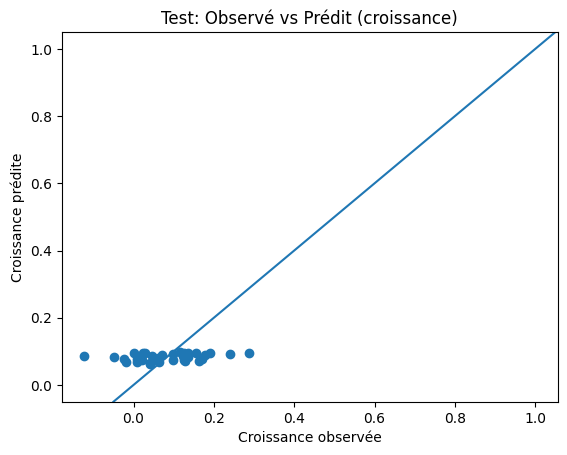

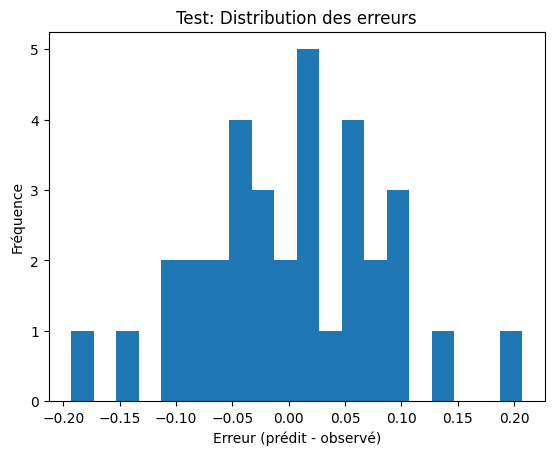

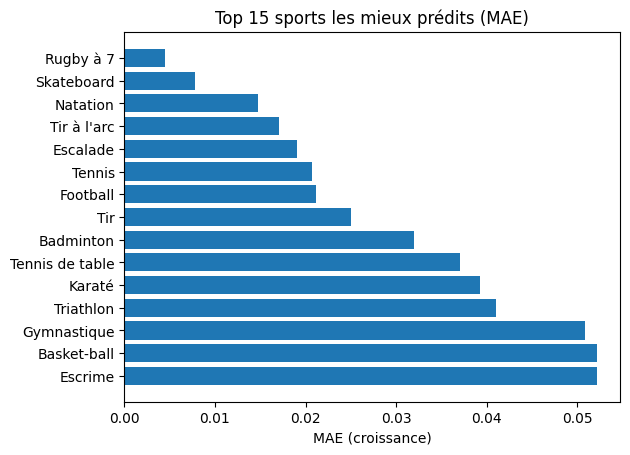

In [12]:

# ==========================================================
# 0) Choisis le DF de travail (adapte si besoin)
# ==========================================================
# df_effect doit contenir: sport, annee, growth + features
df_work = df_effect.copy()  # <-- si ton DF s'appelle df_sport, remplace ici

# ==========================================================
# 1) Définition des features (robuste : garde seulement celles qui existent)
# ==========================================================
candidate_features = [
    'sport',
    'annees_depuis_jo',
    'or', 'argent', 'bronze', 'total_medailles',
    'nb_licencies_lag1',          # utile si dispo
    'age_mean_lag1',              # utile si dispo
    'part_femmes_lag1',           # utile si dispo
    'nb_departements_actifs',     # utile si dispo
]

features = [c for c in candidate_features if c in df_work.columns]

print("Features utilisées :", features)

# ==========================================================
# 2) Split temporel (ex: train 2021-2022, test 2023)
# ==========================================================
train_df = df_work[df_work['annee'] <= 2022].copy()
test_df  = df_work[df_work['annee'] == 2023].copy()

print("Train years:", train_df['annee'].min(), "->", train_df['annee'].max(), "| n =", len(train_df))
print("Test year:", test_df['annee'].unique(), "| n =", len(test_df))

# Sécurité : enlever les NaN de la cible
train_df = train_df.dropna(subset=['growth']).copy()
test_df  = test_df.dropna(subset=['growth']).copy()

# ==========================================================
# 3) X/y
# ==========================================================
X_train = train_df[features].copy()
y_train = train_df['growth'].copy()

X_test  = test_df[features].copy()
y_test  = test_df['growth'].copy()

# Cat features
cat_features = ['sport'] if 'sport' in features else []

# Cast catégorielles sans warning (avec .loc)
for c in cat_features:
    X_train.loc[:, c] = X_train[c].astype('string').fillna('MISSING').astype(str)
    X_test.loc[:, c]  = X_test[c].astype('string').fillna('MISSING').astype(str)

# (Optionnel) remplir NaN numériques
num_cols = [c for c in features if c not in cat_features]
X_train[num_cols] = X_train[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test[num_cols]  = X_test[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

# ==========================================================
# 4) Modèle CatBoost
# ==========================================================
model = CatBoostRegressor(
    loss_function='RMSE',
    iterations=2000,
    learning_rate=0.05,
    depth=5,
    random_seed=42,
    od_type='Iter',
    od_wait=150,
    verbose=200
)

model.fit(train_pool, eval_set=test_pool, use_best_model=True)

# ==========================================================
# 5) Prédictions + métriques globales
# ==========================================================
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("\n=== PERF GLOBALE (test) ===")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# Ajoute les prédictions au test_df
test_df = test_df.copy()
test_df['pred_growth'] = pred
test_df['abs_err'] = np.abs(test_df['growth'] - test_df['pred_growth'])
test_df['sq_err'] = (test_df['growth'] - test_df['pred_growth'])**2

# ==========================================================
# 6) Métriques PAR SPORT
# ==========================================================
def rmse_series(x):
    return float(np.sqrt(np.mean(x)))

agg_dict = {
    'growth': ['count', 'mean'],
    'pred_growth': ['mean'],
    'abs_err': ['mean'],
    'sq_err': ['mean']
}

sport_eval = test_df.groupby('sport').agg(agg_dict)
sport_eval.columns = ['n_obs', 'growth_mean', 'pred_mean', 'mae', 'mse']
sport_eval = sport_eval.reset_index()
sport_eval['rmse'] = sport_eval['mse'].apply(lambda v: float(np.sqrt(v)))
sport_eval['bias'] = sport_eval['pred_mean'] - sport_eval['growth_mean']
sport_eval['abs_bias'] = np.abs(sport_eval['bias'])

# Optionnel : garder médailles si dispo (utile pour interprétation)
if 'total_medailles' in test_df.columns:
    med = test_df.groupby('sport')['total_medailles'].first().reset_index()
    sport_eval = sport_eval.merge(med, on='sport', how='left')

sport_eval = sport_eval.sort_values('mae')

print("\n=== TOP 10 SPORTS LES MIEUX PRÉDITS (MAE faible) ===")
cols_show = ['sport', 'n_obs', 'mae', 'rmse', 'abs_bias']
if 'total_medailles' in sport_eval.columns: cols_show += ['total_medailles']
print(sport_eval.head(10)[cols_show])

print("\n=== TOP 10 SPORTS LES PLUS MAL PRÉDITS (MAE élevé) ===")
print(sport_eval.tail(10)[cols_show])

# ==========================================================
# 7) Graphiques utiles
# ==========================================================
# 7A) Observé vs Prédit (global)
plt.figure()
plt.scatter(test_df['growth'], test_df['pred_growth'])
plt.xlabel("Croissance observée")
plt.ylabel("Croissance prédite")
plt.title("Test: Observé vs Prédit (croissance)")
plt.axline((0,0),(1,1))
plt.show()

# 7B) Distribution des erreurs
plt.figure()
plt.hist(test_df['pred_growth'] - test_df['growth'], bins=20)
plt.xlabel("Erreur (prédit - observé)")
plt.ylabel("Fréquence")
plt.title("Test: Distribution des erreurs")
plt.show()

# 7C) Barplot MAE par sport (top 15)
top15 = sport_eval.head(15).copy()
plt.figure()
plt.barh(top15['sport'].astype(str), top15['mae'])
plt.xlabel("MAE (croissance)")
plt.title("Top 15 sports les mieux prédits (MAE)")
plt.gca().invert_yaxis()
plt.show()

# ==========================================================
# 8) Sauvegarde optionnelle des résultats
# ==========================================================
# sport_eval.to_csv("sport_eval_2023.csv", index=False)
# test_df[['sport','annee','growth','pred_growth','abs_err']].to_csv("predictions_2023.csv", index=False)


In [11]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------- 1) Construire une table "croissance" sur plusieurs années ----------
df = df_model.copy()
df = df.sort_values(['code_sport', 'annee']).reset_index(drop=True)

# growth = (t - t-1) / (t-1)
df['growth'] = (df['nb_licencies'] - df['nb_licencies_lag1']) / df['nb_licencies_lag1']
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['growth'])

# ---------- 2) Choisir features (robuste) ----------
candidate_features = [
    'sport',
    'annees_depuis_jo',
    'or', 'argent', 'bronze', 'total_medailles',
    'nb_licencies_lag1'
]
features = [c for c in candidate_features if c in df.columns]
cat_features = ['sport'] if 'sport' in features else []

# Remplir NaN numériques si besoin
num_cols = [c for c in features if c not in cat_features]
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# ---------- 3) Walk-forward: on prédit plusieurs années ----------
def walk_forward_predictions(df, features, cat_features, start_test_year=2019, end_test_year=2024):
    preds_all = []

    for test_year in range(start_test_year, end_test_year + 1):
        train_df = df[df['annee'] < test_year].copy()
        test_df  = df[df['annee'] == test_year].copy()

        # Il faut des données
        if len(train_df) < 30 or len(test_df) == 0:
            continue

        X_train = train_df[features].copy()
        y_train = train_df['growth'].copy()
        X_test  = test_df[features].copy()
        y_test  = test_df['growth'].copy()

        # catégorielle propre
        for c in cat_features:
            X_train.loc[:, c] = X_train[c].astype('string').fillna('MISSING').astype(str)
            X_test.loc[:, c]  = X_test[c].astype('string').fillna('MISSING').astype(str)

        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        test_pool  = Pool(X_test, y_test, cat_features=cat_features)

        model = CatBoostRegressor(
            loss_function='RMSE',
            iterations=3000,
            learning_rate=0.05,
            depth=5,
            random_seed=42,
            od_type='Iter',
            od_wait=200,
            verbose=False
        )

        model.fit(train_pool, eval_set=test_pool, use_best_model=True)

        pred = model.predict(X_test)

        out = test_df[['code_sport','sport','annee','growth']].copy()
        out['pred_growth'] = pred
        preds_all.append(out)

    return pd.concat(preds_all, ignore_index=True)

preds = walk_forward_predictions(df, features, cat_features, start_test_year=2019, end_test_year=2024)

print("Nb prédictions totales:", len(preds))
print(preds.head())

# ---------- 4) Métriques globales ----------
mae = mean_absolute_error(preds['growth'], preds['pred_growth'])
rmse = np.sqrt(mean_squared_error(preds['growth'], preds['pred_growth']))
r2 = r2_score(preds['growth'], preds['pred_growth'])

print("\n=== PERF GLOBALE (multi-années) ===")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ---------- 5) Métriques PAR SPORT (enfin pertinentes) ----------
sport_eval = (
    preds
    .assign(abs_err=lambda d: np.abs(d['growth'] - d['pred_growth']),
            sq_err=lambda d: (d['growth'] - d['pred_growth'])**2)
    .groupby('sport')
    .agg(
        n_obs=('growth','size'),
        mae=('abs_err','mean'),
        rmse=('sq_err', lambda x: float(np.sqrt(np.mean(x)))),
        bias=('pred_growth','mean')
    )
    .reset_index()
)

# On ne garde que les sports avec assez d'observations (>=3 ans par ex)
sport_eval = sport_eval[sport_eval['n_obs'] >= 3].sort_values('mae')

print("\n=== TOP 10 sports les mieux prédits (n_obs >= 3) ===")
print(sport_eval.head(10))

print("\n=== TOP 10 sports les plus mal prédits (n_obs >= 3) ===")
print(sport_eval.tail(10))


Nb prédictions totales: 204
  code_sport        sport  annee    growth  pred_growth
0        ATH   Athlétisme   2019  0.006537     0.007569
1        AVI       Aviron   2019  0.143742    -0.007810
2        BAD    Badminton   2019  0.014927     0.004909
3        BAK  Basket-ball   2019 -0.016481     0.006111
4        BAS          NaN   2019 -0.120234     0.003566

=== PERF GLOBALE (multi-années) ===
MAE : 0.1121
RMSE: 0.1729
R²  : -0.0556

=== TOP 10 sports les mieux prédits (n_obs >= 3) ===
         sport  n_obs       mae      rmse      bias
26         Tir      6  0.027964  0.046544  0.008481
10        Golf      6  0.035183  0.043201  0.007296
24      Tennis      6  0.035979  0.046621  0.010722
6     Cyclisme      6  0.046071  0.051938  0.011625
31  Équitation      6  0.050680  0.059221  0.011005
20   Rugby à 7      6  0.055136  0.068046  0.010061
9     Football      6  0.061361  0.073430  0.007876
1       Aviron      6  0.065864  0.081903  0.012465
0   Athlétisme      6  0.067473  0.10

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_17988\2712171939.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sport')



=== Perf modèle : sports médaillés vs non-médaillés ===
             n_obs       mae      rmse  bias_mean  growth_mean
is_medaille                                                   
False           66  0.114388  0.167472   0.007626     0.026096
True           138  0.111013  0.175465   0.008844     0.027516

=== TOP 10 sports médaillés les MIEUX prédits (MAE faible) ===
         sport  n_obs       mae      rmse      bias  total_medailles
0          Tir      6  0.027964  0.046544  0.008481              2.0
3     Cyclisme      6  0.046071  0.051938  0.011625              9.0
4   Équitation      6  0.050680  0.059221  0.011005              3.0
5    Rugby à 7      6  0.055136  0.068046  0.010061              1.0
6     Football      6  0.061361  0.073430  0.007876              1.0
7       Aviron      6  0.065864  0.081903  0.012465              2.0
8   Athlétisme      6  0.067473  0.101221  0.007078              6.0
9         Surf      6  0.070652  0.088278  0.006228              2.0
10   T

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_17988\29728650.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby('sport')['total_medailles']


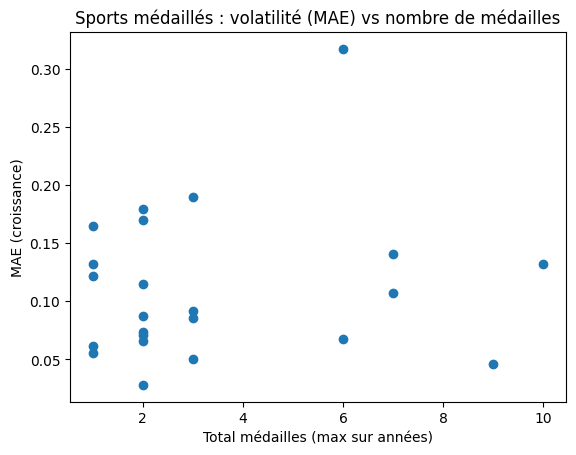

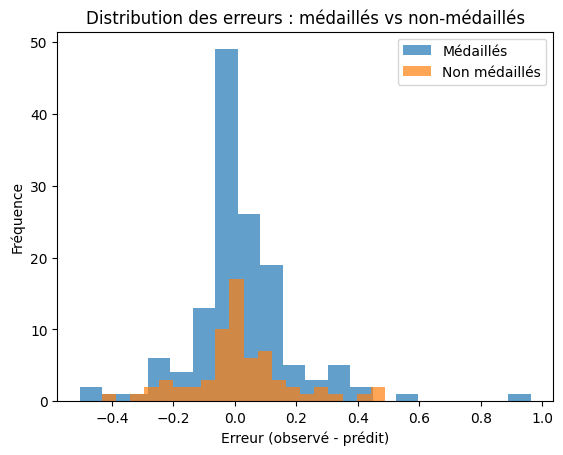

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_17988\29728650.py:91: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sport')


KeyError: 'Column(s) [<function <lambda> at 0x000001DF633DEDE0>] do not exist'

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FOCUS SPORTS MÉDAILLÉS (BLOC UNIQUE)
# Requiert: preds, sport_eval, df_model
# preds doit contenir au moins: sport, growth, pred_growth
# sport_eval doit contenir au moins: sport, n_obs, mae, rmse, bias
# df_model doit contenir: sport + total_medailles (par sport/année)
# ==========================================================

# --- 0) Sécurités + copies
preds = preds.copy()
sport_eval = sport_eval.copy()

# --- 1) Reconstruire "médailles par sport" depuis df_model (max sur années)
if 'sport' not in df_model.columns:
    raise ValueError("df_model n'a pas la colonne 'sport'.")
if 'total_medailles' not in df_model.columns:
    raise ValueError("df_model n'a pas la colonne 'total_medailles'. (Tu dois l'avoir jointe depuis df_med)")

med_by_sport = (
    df_model.groupby('sport')['total_medailles']
    .max()
    .fillna(0)
    .reset_index()
)

# --- 2) Joindre les médailles à preds (si absent)
if 'total_medailles' not in preds.columns:
    preds = preds.merge(med_by_sport, on='sport', how='left')

preds['total_medailles'] = preds['total_medailles'].fillna(0)
preds['is_medaille'] = preds['total_medailles'] > 0

# --- 3) Qualité du modèle : médaillés vs non-médaillés
preds['abs_err'] = np.abs(preds['growth'] - preds['pred_growth'])
preds['sq_err'] = (preds['growth'] - preds['pred_growth'])**2

eval_med = (
    preds.groupby('is_medaille')
    .agg(
        n_obs=('growth','size'),
        mae=('abs_err','mean'),
        rmse=('sq_err', lambda x: float(np.sqrt(np.mean(x)))),
        bias_mean=('pred_growth','mean'),
        growth_mean=('growth','mean')
    )
)

print("\n=== Perf modèle : sports médaillés vs non-médaillés ===")
print(eval_med)

# --- 4) Joindre médailles à sport_eval et filtrer sports médaillés
if 'total_medailles' not in sport_eval.columns:
    sport_eval = sport_eval.merge(med_by_sport, on='sport', how='left')

sport_eval['total_medailles'] = sport_eval['total_medailles'].fillna(0)
sport_eval_med = sport_eval[sport_eval['total_medailles'] > 0].sort_values('mae')

print("\n=== TOP 10 sports médaillés les MIEUX prédits (MAE faible) ===")
print(sport_eval_med.head(10)[['sport','n_obs','mae','rmse','bias','total_medailles']])

print("\n=== TOP 10 sports médaillés les PLUS MAL prédits (MAE élevé) ===")
print(sport_eval_med.tail(10)[['sport','n_obs','mae','rmse','bias','total_medailles']])

# --- 5) Graphique 1 : MAE vs nombre de médailles (sports médaillés)
plt.figure()
plt.scatter(sport_eval_med['total_medailles'], sport_eval_med['mae'])
plt.xlabel("Total médailles (max sur années)")
plt.ylabel("MAE (croissance)")
plt.title("Sports médaillés : volatilité (MAE) vs nombre de médailles")
plt.show()

# --- 6) Graphique 2 : distribution des erreurs (médaillés vs non)
plt.figure()
plt.hist((preds.loc[preds['is_medaille'], 'growth'] - preds.loc[preds['is_medaille'], 'pred_growth']),
         bins=20, alpha=0.7, label='Médaillés')
plt.hist((preds.loc[~preds['is_medaille'], 'growth'] - preds.loc[~preds['is_medaille'], 'pred_growth']),
         bins=20, alpha=0.7, label='Non médaillés')
plt.xlabel("Erreur (observé - prédit)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs : médaillés vs non-médaillés")
plt.legend()
plt.show()

# --- 7) Bonus utile : sur/sous-performance par sport médaillé (résidu moyen)
# (positif = croissance observée > prédite)
med_resid = (
    preds[preds['is_medaille']]
    .groupby('sport')
    .agg(
        n_obs=('growth','size'),
        resid_mean=(lambda x: 0, 'size')  # placeholder
    )
)

# recalcul propre du résidu moyen
tmp = preds[preds['is_medaille']].copy()
tmp['resid'] = tmp['growth'] - tmp['pred_growth']
med_resid = tmp.groupby('sport').agg(n_obs=('resid','size'), resid_mean=('resid','mean')).reset_index()
med_resid = med_resid.sort_values('resid_mean', ascending=False)

print("\n=== Sports médaillés : surperformance moyenne (growth - pred_growth) ===")
print(med_resid.head(10))
print("\n=== Sports médaillés : sous-performance moyenne (growth - pred_growth) ===")
print(med_resid.tail(10))


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FOCUS SPORTS MÉDAILLÉS — BLOC UNIQUE CORRIGÉ
# Requiert : preds, sport_eval, df_model
# ==========================================================

preds = preds.copy()
sport_eval = sport_eval.copy()

# ---------- 1) Reconstruire les médailles par sport ----------
med_by_sport = (
    df_model
    .groupby('sport')['total_medailles']
    .max()
    .fillna(0)
    .reset_index()
)

# ---------- 2) Joindre les médailles à preds ----------
preds = preds.merge(med_by_sport, on='sport', how='left')
preds['total_medailles'] = preds['total_medailles'].fillna(0)
preds['is_medaille'] = preds['total_medailles'] > 0

# ---------- 3) Qualité du modèle : médaillés vs non-médaillés ----------
preds['abs_err'] = np.abs(preds['growth'] - preds['pred_growth'])
preds['sq_err'] = (preds['growth'] - preds['pred_growth'])**2
preds['resid'] = preds['growth'] - preds['pred_growth']

eval_med = (
    preds.groupby('is_medaille')
    .agg(
        n_obs=('growth','size'),
        mae=('abs_err','mean'),
        rmse=('sq_err', lambda x: float(np.sqrt(np.mean(x)))),
        resid_mean=('resid','mean'),
        growth_mean=('growth','mean')
    )
)

print("\n=== Performance modèle : sports médaillés vs non-médaillés ===")
print(eval_med)

# ---------- 4) Classement des SPORTS MÉDAILLÉS ----------
sport_eval = sport_eval.merge(med_by_sport, on='sport', how='left')
sport_eval['total_medailles'] = sport_eval['total_medailles'].fillna(0)

sport_eval_med = sport_eval[sport_eval['total_medailles'] > 0].sort_values('mae')

print("\n=== TOP 10 sports médaillés les MIEUX prédits ===")
print(sport_eval_med.head(10)[['sport','n_obs','mae','rmse','bias','total_medailles']])

print("\n=== TOP 10 sports médaillés les PLUS MAL prédits ===")
print(sport_eval_med.tail(10)[['sport','n_obs','mae','rmse','bias','total_medailles']])

# ---------- 5) Graphique : volatilité vs nombre de médailles ----------
plt.figure()
plt.scatter(sport_eval_med['total_medailles'], sport_eval_med['mae'])
plt.xlabel("Total médailles (max sur JO)")
plt.ylabel("MAE (croissance)")
plt.title("Sports médaillés : volatilité vs nombre de médailles")
plt.show()

# ---------- 6) Sur / sous-performance moyenne par sport médaillé ----------
med_resid = (
    preds[preds['is_medaille']]
    .groupby('sport')
    .agg(
        n_obs=('resid','size'),
        resid_mean=('resid','mean')
    )
    .reset_index()
    .sort_values('resid_mean', ascending=False)
)

print("\n=== Sports médaillés : SUR-performance moyenne ===")
print(med_resid.head(10))

print("\n=== Sports médaillés : SOUS-performance moyenne ===")
print(med_resid.tail(10))


C:\Users\mcmoi\AppData\Local\Temp\ipykernel_17988\2590800053.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sport')['total_medailles']


KeyError: 'total_medailles'

Source médailles utilisée : df_med.total_medailles_2024+total_medailles_2020+total_medailles_2016 (max)

=== Performance modèle : sports médaillés vs non-médaillés ===
             n_obs       mae      rmse  resid_mean  growth_mean
is_medaille                                                    
False           66  0.114388  0.167472    0.018470     0.026096
True           138  0.111013  0.175465    0.018673     0.027516

=== TOP 10 sports médaillés les MIEUX prédits ===
         sport  n_obs       mae      rmse      bias  total_medailles_ref
0          Tir      6  0.027964  0.046544  0.008481                  2.0
3     Cyclisme      6  0.046071  0.051938  0.011625                  9.0
4   Équitation      6  0.050680  0.059221  0.011005                  3.0
5    Rugby à 7      6  0.055136  0.068046  0.010061                  1.0
6     Football      6  0.061361  0.073430  0.007876                  1.0
7       Aviron      6  0.065864  0.081903  0.012465                  2.0
8   Athlétisme

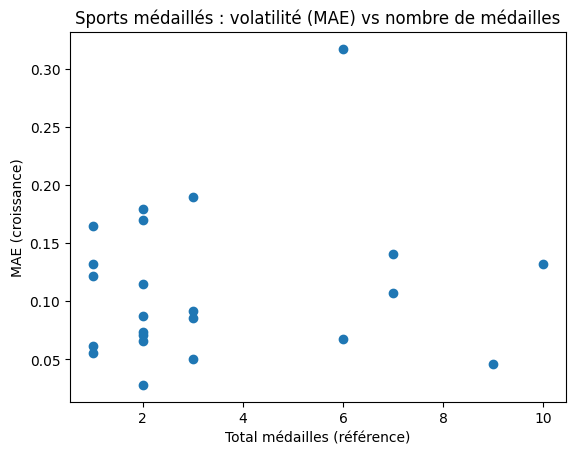


=== Sports médaillés : SUR-performance moyenne (growth - pred) ===
                 sport  n_obs  resid_mean
3                 Boxe      6    0.104527
21         Volley-ball      6    0.082113
11            Natation      6    0.054327
12  Pentathlon moderne      6    0.038950
8             Handball      6    0.038561
19           Triathlon      6    0.029471
13           Rugby à 7      6    0.028936
20               Voile      6    0.026910
17                 Tir      6    0.026786
2          Basket-ball      6    0.020636

=== Sports médaillés : SOUS-performance moyenne (growth - pred) ===
              sport  n_obs  resid_mean
16  Tennis de table      6    0.012667
10           Karaté      6    0.010861
15        Taekwondo      6    0.010267
18      Tir à l'arc      6    0.005644
0        Athlétisme      6   -0.003127
22       Équitation      6   -0.004481
6           Escrime      6   -0.011471
14             Surf      6   -0.014032
5          Cyclisme      6   -0.023317
4       Can

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FOCUS SPORTS MÉDAILLÉS — BLOC UNIQUE ROBUSTE
# Requiert : preds, sport_eval, (df_model OU df_med)
# preds : colonnes min = ['sport','growth','pred_growth']
# sport_eval : colonnes min = ['sport','n_obs','mae','rmse','bias']
# ==========================================================

# --- 0) Copies
preds = preds.copy()
sport_eval = sport_eval.copy()

# --- 1) Construire med_by_sport en trouvant automatiquement la bonne colonne médailles
def build_med_by_sport():
    # On préfère df_med si présent (c'est la source "médailles" la plus propre)
    sources = []
    if 'df_med' in globals() and isinstance(df_med, (type(preds),)):  # DataFrame
        sources.append(('df_med', df_med))
    if 'df_model' in globals() and isinstance(df_model, (type(preds),)):
        sources.append(('df_model', df_model))

    if not sources:
        raise ValueError("Je ne trouve ni df_med ni df_model. Il me faut au moins l'un des deux.")

    # Colonnes possibles
    medal_candidates = [
        'total_medailles',              # parfois déjà long
        'total_medailles_2024',
        'total_medailles_2020',
        'total_medailles_2016',
        'total_medailles_max'           # au cas où
    ]

    for name, df_src in sources:
        if 'sport' not in df_src.columns:
            continue

        # Si on a une colonne "total_medailles" directe
        if 'total_medailles' in df_src.columns:
            med = (df_src.groupby('sport')['total_medailles']
                   .max()
                   .fillna(0)
                   .reset_index()
                   .rename(columns={'total_medailles': 'total_medailles_ref'}))
            return med, f"{name}.total_medailles"

        # Sinon, on prend le max des colonnes *_2020/_2024/_2016 disponibles
        cols = [c for c in medal_candidates if c in df_src.columns and c != 'total_medailles']
        if cols:
            tmp = df_src[['sport'] + cols].copy()
            tmp[cols] = tmp[cols].apply(pd.to_numeric, errors='coerce').fillna(0)
            tmp['total_medailles_ref'] = tmp[cols].max(axis=1)
            med = (tmp.groupby('sport')['total_medailles_ref']
                   .max()
                   .fillna(0)
                   .reset_index())
            return med, f"{name}.{'+'.join(cols)} (max)"

    raise ValueError("Impossible de trouver une colonne de médailles dans df_med ou df_model (vérifie les colonnes).")

# pandas utilisé dans build_med_by_sport
import pandas as pd
med_by_sport, medal_source_used = build_med_by_sport()
print("Source médailles utilisée :", medal_source_used)

# --- 2) Joindre les médailles à preds sans ambiguïté
# (on supprime d'abord toute colonne existante qui pourrait entrer en conflit)
for col in ['total_medailles', 'total_medailles_ref', 'is_medaille']:
    if col in preds.columns:
        preds = preds.drop(columns=[col])

preds = preds.merge(med_by_sport, on='sport', how='left')
preds['total_medailles_ref'] = preds['total_medailles_ref'].fillna(0)
preds['is_medaille'] = preds['total_medailles_ref'] > 0

# --- 3) Qualité du modèle : médaillés vs non-médaillés
preds['abs_err'] = np.abs(preds['growth'] - preds['pred_growth'])
preds['sq_err'] = (preds['growth'] - preds['pred_growth'])**2
preds['resid'] = preds['growth'] - preds['pred_growth']

eval_med = (
    preds.groupby('is_medaille')
    .agg(
        n_obs=('growth','size'),
        mae=('abs_err','mean'),
        rmse=('sq_err', lambda x: float(np.sqrt(np.mean(x)))),
        resid_mean=('resid','mean'),
        growth_mean=('growth','mean')
    )
)

print("\n=== Performance modèle : sports médaillés vs non-médaillés ===")
print(eval_med)

# --- 4) Classement des SPORTS MÉDAILLÉS
# joindre la ref médailles à sport_eval (sans casser tes colonnes)
if 'total_medailles_ref' in sport_eval.columns:
    sport_eval = sport_eval.drop(columns=['total_medailles_ref'])
sport_eval = sport_eval.merge(med_by_sport, on='sport', how='left')
sport_eval['total_medailles_ref'] = sport_eval['total_medailles_ref'].fillna(0)

sport_eval_med = sport_eval[sport_eval['total_medailles_ref'] > 0].sort_values('mae')

print("\n=== TOP 10 sports médaillés les MIEUX prédits ===")
print(sport_eval_med.head(10)[['sport','n_obs','mae','rmse','bias','total_medailles_ref']])

print("\n=== TOP 10 sports médaillés les PLUS MAL prédits ===")
print(sport_eval_med.tail(10)[['sport','n_obs','mae','rmse','bias','total_medailles_ref']])

# --- 5) Graphique : volatilité vs médailles (sports médaillés)
plt.figure()
plt.scatter(sport_eval_med['total_medailles_ref'], sport_eval_med['mae'])
plt.xlabel("Total médailles (référence)")
plt.ylabel("MAE (croissance)")
plt.title("Sports médaillés : volatilité (MAE) vs nombre de médailles")
plt.show()

# --- 6) Sur / sous-performance moyenne par sport médaillé (résidu moyen)
med_resid = (
    preds[preds['is_medaille']]
    .groupby('sport')
    .agg(n_obs=('resid','size'), resid_mean=('resid','mean'))
    .reset_index()
    .sort_values('resid_mean', ascending=False)
)

print("\n=== Sports médaillés : SUR-performance moyenne (growth - pred) ===")
print(med_resid.head(10))

print("\n=== Sports médaillés : SOUS-performance moyenne (growth - pred) ===")
print(med_resid.tail(10))


Candidats Hand trouvés : ['Handball']
Sport sélectionné pour le focus : Handball

=== PERF HANDBALL (croissance) ===
n_obs: 6
MAE : 0.1702
RMSE: 0.2107
Bias (pred-true): -0.0386
R²  : -0.198948354654785


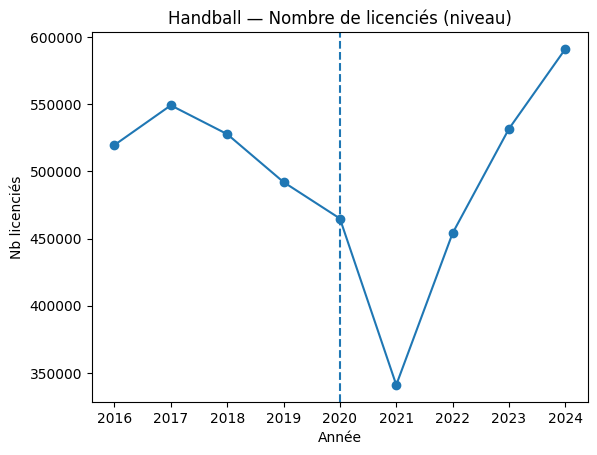

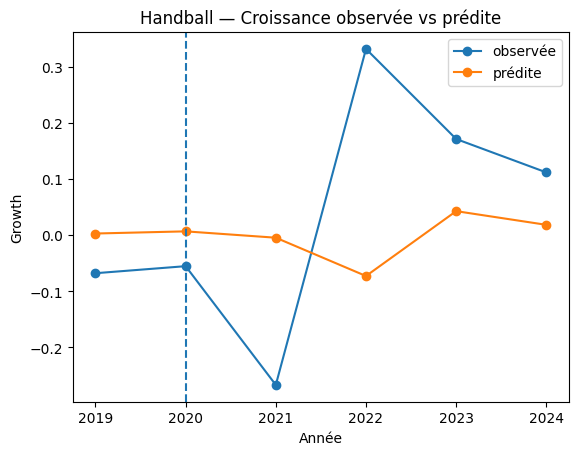


=== HANDBALL : croissance moyenne ===
Avant 2020 (jusqu'à 2020 inclus si présent): -0.0614366281783246
Après JO 2020 (2021+): 0.08704016449412788
Diff (post - pre): 0.14847679267245248

=== Résidu par année (growth - pred_growth) ===
   annee    growth  pred_growth     resid
0   2019 -0.067710     0.002986 -0.070695
1   2020 -0.055163     0.006831 -0.061994
2   2021 -0.266652    -0.004473 -0.262179
3   2022  0.331732    -0.072687  0.404419
4   2023  0.171285     0.042820  0.128465
5   2024  0.111795     0.018443  0.093352


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# FOCUS HANDBALL — BLOC UNIQUE
# Requiert : df_model, preds (walk-forward) + (optionnel) model/pred_growth déjà dans preds
# df_model : doit contenir sport, annee, nb_licencies (et idéalement nb_licencies_lag1)
# preds : doit contenir sport, annee, growth, pred_growth
# ==========================================================

# ---------- 1) Trouver le bon libellé "hand" dans tes sports ----------
sports_list = df_model['sport'].dropna().astype(str).unique()
hand_candidates = [s for s in sports_list if 'hand' in s.lower()]  # capture "Handball", "Hand", etc.

if len(hand_candidates) == 0:
    raise ValueError("Je ne trouve aucun sport contenant 'hand' dans df_model['sport']. Vérifie l'orthographe exacte.")
print("Candidats Hand trouvés :", hand_candidates)

# si plusieurs candidats, on prend le plus long (souvent 'Handball')
hand_sport = sorted(hand_candidates, key=len, reverse=True)[0]
print("Sport sélectionné pour le focus :", hand_sport)

# ---------- 2) Sous-ensemble HANDBALL dans df_model ----------
df_hand = df_model[df_model['sport'].astype(str) == hand_sport].copy()
df_hand = df_hand.sort_values('annee')

# Vérifier colonnes
for col in ['annee', 'nb_licencies']:
    if col not in df_hand.columns:
        raise ValueError(f"df_model n'a pas la colonne '{col}' nécessaire au focus hand.")

# ---------- 3) Sous-ensemble HANDBALL dans preds (walk-forward) ----------
if 'preds' not in globals():
    raise ValueError("Je ne trouve pas l'objet 'preds'. Il faut d'abord exécuter le walk-forward.")

preds_hand = preds[preds['sport'].astype(str) == hand_sport].copy()
preds_hand = preds_hand.sort_values('annee')

if len(preds_hand) == 0:
    raise ValueError("Aucune ligne hand dans preds. Vérifie que preds contient bien 'sport' et les mêmes libellés que df_model.")

# ---------- 4) Métriques sur la croissance (hand uniquement) ----------
y_true = preds_hand['growth'].values
y_pred = preds_hand['pred_growth'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred) if len(preds_hand) >= 3 else np.nan
bias = float(np.mean(y_pred - y_true))

print("\n=== PERF HANDBALL (croissance) ===")
print("n_obs:", len(preds_hand))
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Bias (pred-true): {bias:.4f}")
print(f"R²  : {r2}")

# ---------- 5) Graphe 1 : évolution du NIVEAU de licences (hand) ----------
plt.figure()
plt.plot(df_hand['annee'], df_hand['nb_licencies'], marker='o')
plt.axvline(2020, linestyle='--')
plt.title(f"{hand_sport} — Nombre de licenciés (niveau)")
plt.xlabel("Année")
plt.ylabel("Nb licenciés")
plt.show()

# ---------- 6) Graphe 2 : croissance observée vs prédite (hand) ----------
plt.figure()
plt.plot(preds_hand['annee'], preds_hand['growth'], marker='o', label='observée')
plt.plot(preds_hand['annee'], preds_hand['pred_growth'], marker='o', label='prédite')
plt.axvline(2020, linestyle='--')
plt.title(f"{hand_sport} — Croissance observée vs prédite")
plt.xlabel("Année")
plt.ylabel("Growth")
plt.legend()
plt.show()

# ---------- 7) Bonus : comparaison avant vs après JO 2020 (sur la croissance observée) ----------
preds_hand['post_2020'] = preds_hand['annee'] >= 2021
mean_pre = preds_hand.loc[~preds_hand['post_2020'], 'growth'].mean()
mean_post = preds_hand.loc[preds_hand['post_2020'], 'growth'].mean()

print("\n=== HANDBALL : croissance moyenne ===")
print("Avant 2020 (jusqu'à 2020 inclus si présent):", mean_pre)
print("Après JO 2020 (2021+):", mean_post)
print("Diff (post - pre):", mean_post - mean_pre)

# ---------- 8) Bonus : sur/sous-performance par année (résidu) ----------
preds_hand['resid'] = preds_hand['growth'] - preds_hand['pred_growth']
print("\n=== Résidu par année (growth - pred_growth) ===")
print(preds_hand[['annee','growth','pred_growth','resid']].reset_index(drop=True))


Sport sélectionné : Handball

=== RÉGRESSION LINÉAIRE — HAND ===
                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                 -0.185
Method:                 Least Squares   F-statistic:                    0.4530
Date:                Fri, 19 Dec 2025   Prob (F-statistic):              0.659
Time:                        09:44:15   Log-Likelihood:                 3.5462
No. Observations:                   8   AIC:                            -1.092
Df Residuals:                       5   BIC:                           -0.8541
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

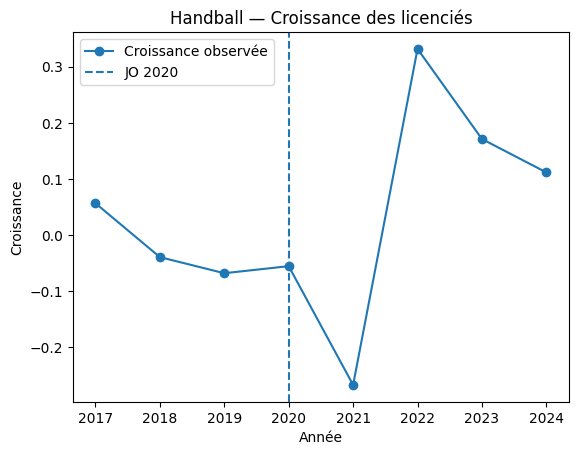

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ==========================================================
# RÉGRESSION SIMPLE — EFFET JO 2020 SUR LE HAND
# ==========================================================

# ---------- 1) Identifier le sport Hand ----------
sports = df_model['sport'].dropna().astype(str).unique()
hand_candidates = [s for s in sports if 'hand' in s.lower()]

if len(hand_candidates) == 0:
    raise ValueError("Aucun sport contenant 'hand' trouvé.")

hand_sport = sorted(hand_candidates, key=len, reverse=True)[0]
print("Sport sélectionné :", hand_sport)

# ---------- 2) Extraire données Hand ----------
df_hand = df_model[df_model['sport'] == hand_sport].copy()
df_hand = df_hand.sort_values('annee')

# ---------- 3) Construire la croissance ----------
df_hand['growth'] = (
    df_hand['nb_licencies']
    .pct_change()
)

df_hand = df_hand.dropna(subset=['growth'])

# ---------- 4) Variables explicatives ----------
df_hand['post_jo_2020'] = (df_hand['annee'] >= 2021).astype(int)
df_hand['trend'] = df_hand['annee'] - df_hand['annee'].min()

X = df_hand[['post_jo_2020', 'trend']]
X = sm.add_constant(X)
y = df_hand['growth']

# ---------- 5) Régression OLS ----------
model = sm.OLS(y, X).fit()

print("\n=== RÉGRESSION LINÉAIRE — HAND ===")
print(model.summary())

# ---------- 6) Visualisation ----------
plt.figure()
plt.plot(df_hand['annee'], df_hand['growth'], marker='o', label='Croissance observée')
plt.axvline(2020, linestyle='--', label='JO 2020')
plt.title(f"{hand_sport} — Croissance des licenciés")
plt.xlabel("Année")
plt.ylabel("Croissance")
plt.legend()
plt.show()


In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================================
# RÉGRESSION SIMPLE — PRÉDICTIONS ET ÉVALUATION PAR SPORT
# ==========================================================

# ---------- 1) Préparer les données ----------
df = df_model.copy()

# Variables nécessaires
required_cols = ['sport', 'annee', 'nb_licencies']
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Colonne manquante : {c}")

# Croissance
df = df.sort_values(['sport', 'annee'])
df['growth'] = df.groupby('sport')['nb_licencies'].pct_change()

# Variables explicatives
df['post_jo_2020'] = (df['annee'] >= 2021).astype(int)
df['trend'] = df['annee'] - df['annee'].min()

# Drop premières années (growth NaN)
df = df.dropna(subset=['growth']).reset_index(drop=True)

# ---------- 2) Split temporel ----------
train_df = df[df['annee'] <= 2022].copy()
test_df  = df[df['annee'] >= 2023].copy()

X_train = train_df[['post_jo_2020', 'trend']]
y_train = train_df['growth']

X_test = test_df[['post_jo_2020', 'trend']]
y_test = test_df['growth']

# ---------- 3) Entraînement ----------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------- 4) Prédictions ----------
test_df['pred_growth'] = model.predict(X_test)

# ---------- 5) ÉVALUATION PAR SPORT ----------
sport_eval = (
    test_df
    .groupby('sport')
    .apply(lambda x: pd.Series({
        'n_obs': len(x),
        'mae': mean_absolute_error(x['growth'], x['pred_growth']),
        'rmse': np.sqrt(mean_squared_error(x['growth'], x['pred_growth'])),
        'bias': np.mean(x['pred_growth'] - x['growth'])
    }))
    .reset_index()
    .sort_values('mae')
)

print("\n=== TOP 10 sports les MIEUX prédits ===")
print(sport_eval.head(10))

print("\n=== TOP 10 sports les PLUS MAL prédits ===")
print(sport_eval.tail(10))

# ---------- 6) Table complète des prédictions ----------
preds = test_df[['sport', 'annee', 'growth', 'pred_growth']].copy()

print("\nNb prédictions totales :", len(preds))
print(preds.head())



=== TOP 10 sports les MIEUX prédits ===
          sport  n_obs       mae      rmse      bias
20    Rugby à 7    2.0  0.020012  0.023250 -0.011835
28    Triathlon    2.0  0.023605  0.023810  0.023605
27  Tir à l'arc    2.0  0.027580  0.038285  0.027580
24       Tennis    2.0  0.027640  0.031282  0.027640
26          Tir    2.0  0.028325  0.028657  0.028325
9      Football    2.0  0.034960  0.035048  0.034960
21   Skateboard    2.0  0.043294  0.046542  0.017082
7      Escalade    2.0  0.050347  0.050789  0.006688
11  Gymnastique    2.0  0.053150  0.053960 -0.009316
13     Handball    2.0  0.055675  0.070266 -0.055675

=== TOP 10 sports les PLUS MAL prédits ===
                 sport  n_obs       mae      rmse      bias
10                Golf    2.0  0.085191  0.087511  0.085191
14    Hockey sur gazon    2.0  0.085857  0.093457  0.085857
23           Taekwondo    2.0  0.089896  0.093720 -0.026498
19  Pentathlon moderne    2.0  0.090133  0.095498  0.090133
6             Cyclisme    2.0  0

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\540779020.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['growth'] = df.groupby('sport')['nb_licencies'].pct_change()
C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\540779020.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sport')



=== Diagnostic pour Handball ===


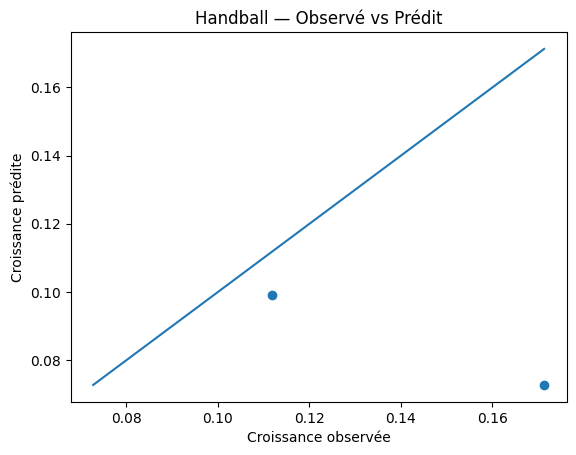

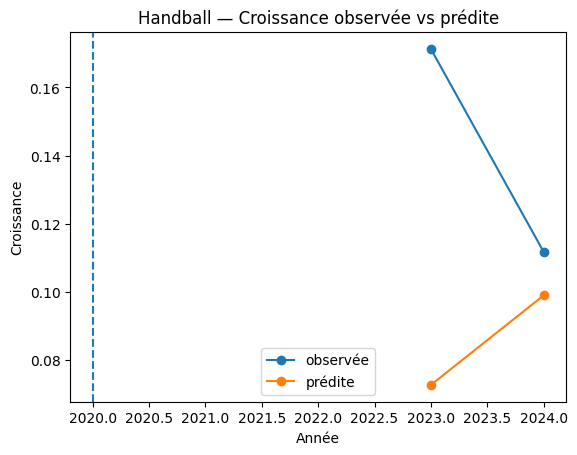

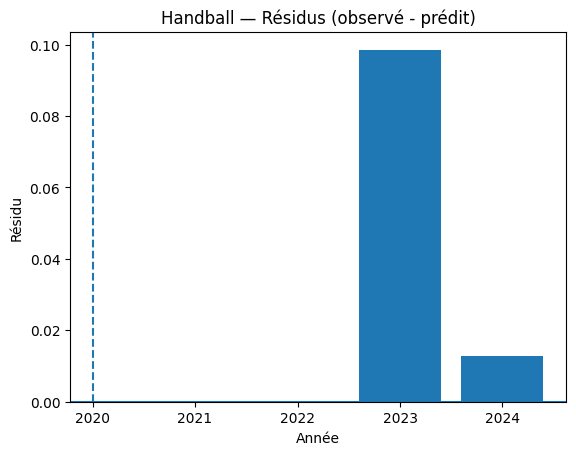

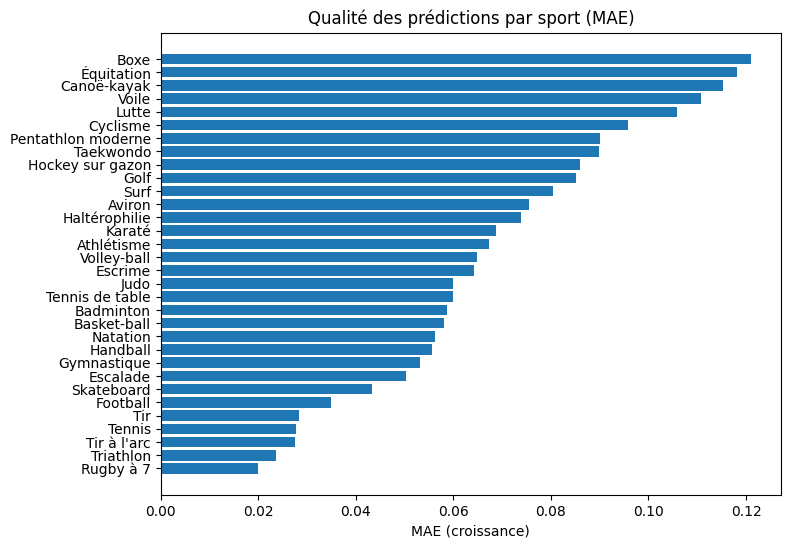

C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\1755390811.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preds.groupby('sport')['growth']


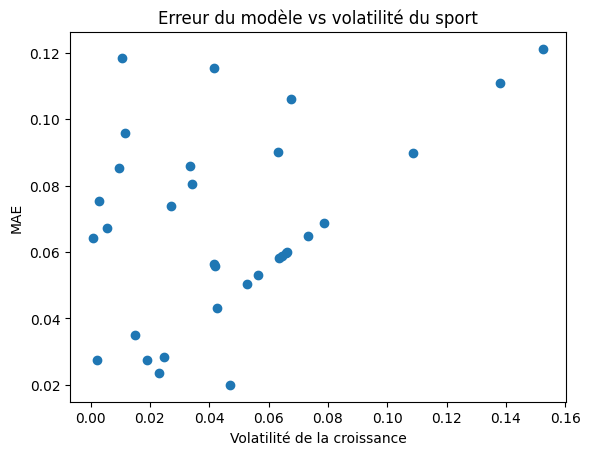

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# VISUALISATIONS — QUALITÉ DES PRÉDICTIONS PAR SPORT
# ==========================================================

# ---------- 1) Fonction de diagnostic pour UN sport ----------
def plot_diagnostics_for_sport(sport_name):
    df_s = preds[preds['sport'] == sport_name].sort_values('annee')

    if len(df_s) < 2:
        print(f"Pas assez d'observations pour {sport_name}")
        return

    # --- A) Observé vs Prédit ---
    plt.figure()
    plt.scatter(df_s['growth'], df_s['pred_growth'])
    lims = [
        min(df_s['growth'].min(), df_s['pred_growth'].min()),
        max(df_s['growth'].max(), df_s['pred_growth'].max())
    ]
    plt.plot(lims, lims)
    plt.xlabel("Croissance observée")
    plt.ylabel("Croissance prédite")
    plt.title(f"{sport_name} — Observé vs Prédit")
    plt.show()

    # --- B) Série temporelle ---
    plt.figure()
    plt.plot(df_s['annee'], df_s['growth'], marker='o', label='observée')
    plt.plot(df_s['annee'], df_s['pred_growth'], marker='o', label='prédite')
    plt.axvline(2020, linestyle='--')
    plt.title(f"{sport_name} — Croissance observée vs prédite")
    plt.xlabel("Année")
    plt.ylabel("Croissance")
    plt.legend()
    plt.show()

    # --- C) Résidus ---
    resid = df_s['growth'] - df_s['pred_growth']
    plt.figure()
    plt.bar(df_s['annee'], resid)
    plt.axhline(0)
    plt.axvline(2020, linestyle='--')
    plt.title(f"{sport_name} — Résidus (observé - prédit)")
    plt.xlabel("Année")
    plt.ylabel("Résidu")
    plt.show()


# ---------- 2) Exemple : focus HAND ----------
sports_focus = [s for s in preds['sport'].unique() if 'hand' in s.lower()]

for s in sports_focus:
    print(f"\n=== Diagnostic pour {s} ===")
    plot_diagnostics_for_sport(s)


# ---------- 3) Comparaison globale : MAE par sport ----------
plt.figure(figsize=(8, 6))
sport_eval_sorted = sport_eval.sort_values('mae')

plt.barh(
    sport_eval_sorted['sport'],
    sport_eval_sorted['mae']
)
plt.xlabel("MAE (croissance)")
plt.title("Qualité des prédictions par sport (MAE)")
plt.show()


# ---------- 4) Bonus : MAE vs volatilité du sport ----------
volatility = (
    preds.groupby('sport')['growth']
    .std()
    .rename('volatility')
    .reset_index()
)

sport_eval_vol = sport_eval.merge(volatility, on='sport', how='left')

plt.figure()
plt.scatter(sport_eval_vol['volatility'], sport_eval_vol['mae'])
plt.xlabel("Volatilité de la croissance")
plt.ylabel("MAE")
plt.title("Erreur du modèle vs volatilité du sport")
plt.show()


C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\1977051700.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['growth'] = df.groupby('sport')['nb_licencies'].pct_change()
C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\1977051700.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preds.groupby('sport')


Train years : [2017 2018 2019 2020]
Test years  : [2021 2024]

=== PERFORMANCE GLOBALE (TEST) ===
MAE : 0.15380254106203534
RMSE: 0.18362743107953364
R²  : -0.27281161924679864

=== TOP 10 sports les MIEUX prédits ===
                 sport  n_obs       mae      rmse      bias
1               Aviron      2  0.059943  0.065468  0.026323
6             Cyclisme      2  0.061869  0.068383  0.061869
26                 Tir      2  0.062880  0.082984  0.062880
24              Tennis      2  0.078151  0.098251  0.078151
10                Golf      2  0.090334  0.094178  0.090334
19  Pentathlon moderne      2  0.097648  0.107177 -0.044179
9             Football      2  0.098505  0.103020  0.030167
31          Équitation      2  0.102547  0.116498  0.102547
0           Athlétisme      2  0.105390  0.106459 -0.015051
20           Rugby à 7      2  0.114886  0.145784  0.114886

=== TOP 10 sports les PLUS MAL prédits ===
            sport  n_obs       mae      rmse      bias
2       Badminton      

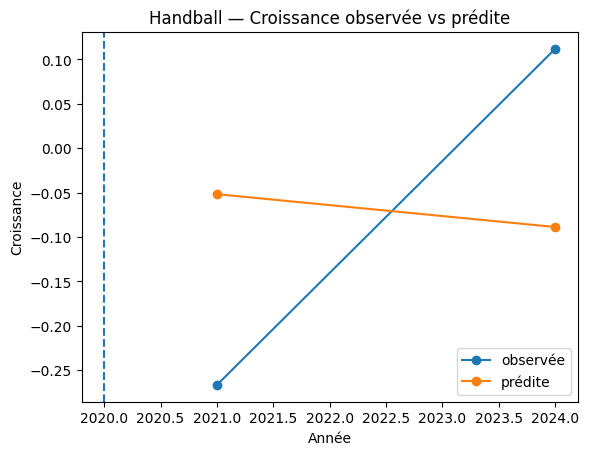

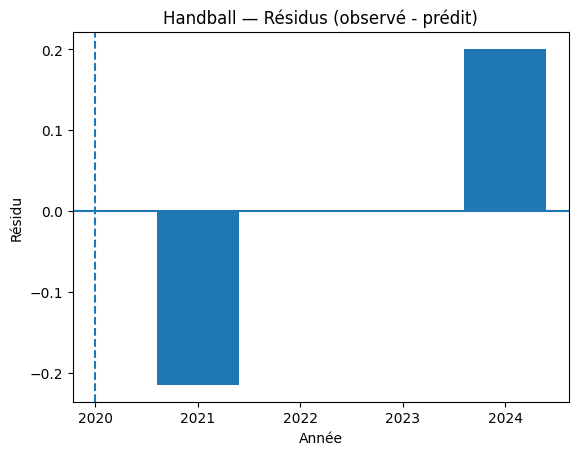

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# PANEL RÉGRESSION — TRAIN 2016-2020 / TEST 2021 & 2024
# ==========================================================

df = df_model.copy()

# ---------- 1) Construction de la croissance ----------
df = df.sort_values(['sport', 'annee'])
df['growth'] = df.groupby('sport')['nb_licencies'].pct_change()
df = df.dropna(subset=['growth']).copy()

# ---------- 2) Variables explicatives ----------
df['post_jo_2020'] = (df['annee'] >= 2021).astype(int)
df['trend'] = df['annee'] - df['annee'].min()

# ---------- 3) Split temporel ----------
train_df = df[(df['annee'] >= 2016) & (df['annee'] <= 2020)].copy()
test_df  = df[df['annee'].isin([2021, 2024])].copy()

print("Train years :", train_df['annee'].unique())
print("Test years  :", test_df['annee'].unique())

# ---------- 4) One-hot sport (effets fixes) ----------
X_train = pd.get_dummies(
    train_df[['sport', 'trend']],
    columns=['sport'],
    drop_first=True
)

X_test = pd.get_dummies(
    test_df[['sport', 'trend']],
    columns=['sport'],
    drop_first=True
)

# Alignement des colonnes (CRUCIAL)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['growth'].values
y_test  = test_df['growth'].values

# ---------- 5) Modèle ----------
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred = model.predict(X_test)

# ---------- 6) Prédictions ----------
preds = test_df[['sport', 'annee', 'growth']].copy()
preds['pred_growth'] = pred
preds['abs_err'] = np.abs(preds['growth'] - preds['pred_growth'])
preds['sq_err'] = (preds['growth'] - preds['pred_growth'])**2
preds['resid'] = preds['growth'] - preds['pred_growth']

# ---------- 7) Performance globale ----------
print("\n=== PERFORMANCE GLOBALE (TEST) ===")
print("MAE :", mean_absolute_error(preds['growth'], preds['pred_growth']))
print("RMSE:", np.sqrt(mean_squared_error(preds['growth'], preds['pred_growth'])))
print("R²  :", r2_score(preds['growth'], preds['pred_growth']))

# ---------- 8) Performance PAR SPORT ----------
sport_eval = (
    preds.groupby('sport')
    .agg(
        n_obs=('growth', 'size'),
        mae=('abs_err', 'mean'),
        rmse=('sq_err', lambda x: float(np.sqrt(np.mean(x)))),
        bias=('resid', 'mean')
    )
    .reset_index()
    .sort_values('mae')
)

print("\n=== TOP 10 sports les MIEUX prédits ===")
print(sport_eval.head(10))

print("\n=== TOP 10 sports les PLUS MAL prédits ===")
print(sport_eval.tail(10))

# ---------- 9) Focus HAND (graphes) ----------
hand_candidates = [s for s in preds['sport'].astype(str).unique() if 'hand' in s.lower()]

if len(hand_candidates) == 0:
    print("\nAucun sport 'hand' trouvé.")
else:
    hand_sport = sorted(hand_candidates, key=len, reverse=True)[0]
    df_hand = preds[preds['sport'] == hand_sport].sort_values('annee')

    # Observé vs prédit
    plt.figure()
    plt.plot(df_hand['annee'], df_hand['growth'], marker='o', label='observée')
    plt.plot(df_hand['annee'], df_hand['pred_growth'], marker='o', label='prédite')
    plt.axvline(2020, linestyle='--')
    plt.title(f"{hand_sport} — Croissance observée vs prédite")
    plt.xlabel("Année")
    plt.ylabel("Croissance")
    plt.legend()
    plt.show()

    # Résidus
    plt.figure()
    plt.bar(df_hand['annee'], df_hand['resid'])
    plt.axhline(0)
    plt.axvline(2020, linestyle='--')
    plt.title(f"{hand_sport} — Résidus (observé - prédit)")
    plt.xlabel("Année")
    plt.ylabel("Résidu")
    plt.show()


C:\Users\mcmoi\AppData\Local\Temp\ipykernel_9572\3517389876.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['log_lic_lag1'] = df.groupby('sport')['log_lic'].shift(1)


Train years : [2017, 2018, 2019, 2020]
Test years  : [2022, 2023, 2024]

=== PERFORMANCE GLOBALE ===
MAE : 41379.62051557498
RMSE: 71814.40672448558
R²  : 0.9713805797560131


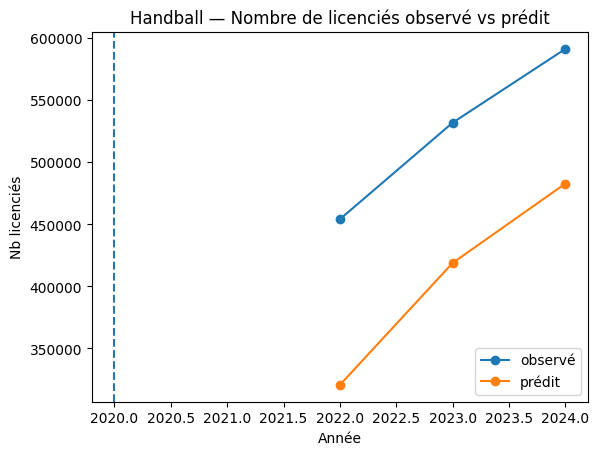

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# PRÉDICTION DU NIVEAU DE LICENCIÉS
# Train : 2016–2020
# Test  : 2022–2024
# ==========================================================

df = df_model.copy()

# ---------- 1) Préparation ----------
df = df.sort_values(['sport','annee'])

# log du nombre de licenciés
df['log_lic'] = np.log(df['nb_licencies'])

# lag
df['log_lic_lag1'] = df.groupby('sport')['log_lic'].shift(1)

# variables temporelles
df['trend'] = df['annee'] - df['annee'].min()
df['post_jo_2020'] = (df['annee'] >= 2021).astype(int)

# drop lignes impossibles
df = df.dropna(subset=['log_lic_lag1']).copy()

# ---------- 2) Split ----------
train_df = df[(df['annee'] >= 2016) & (df['annee'] <= 2020)].copy()
test_df  = df[(df['annee'] >= 2022) & (df['annee'] <= 2024)].copy()

print("Train years :", sorted(train_df['annee'].unique()))
print("Test years  :", sorted(test_df['annee'].unique()))

# ---------- 3) Effets fixes sport ----------
X_train = pd.get_dummies(
    train_df[['sport','log_lic_lag1','trend']],
    columns=['sport'],
    drop_first=True
)

X_test = pd.get_dummies(
    test_df[['sport','log_lic_lag1','trend']],
    columns=['sport'],
    drop_first=True
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['log_lic'].values
y_test  = test_df['log_lic'].values

# ---------- 4) Modèle ----------
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_log = model.predict(X_test)

# ---------- 5) Résultats ----------
preds = test_df[['sport','annee','nb_licencies']].copy()
preds['pred_log_lic'] = pred_log
preds['pred_nb_licencies'] = np.exp(pred_log)

preds['abs_err'] = np.abs(preds['nb_licencies'] - preds['pred_nb_licencies'])

print("\n=== PERFORMANCE GLOBALE ===")
print("MAE :", mean_absolute_error(preds['nb_licencies'], preds['pred_nb_licencies']))
print("RMSE:", np.sqrt(mean_squared_error(preds['nb_licencies'], preds['pred_nb_licencies'])))
print("R²  :", r2_score(preds['nb_licencies'], preds['pred_nb_licencies']))

# ---------- 6) Focus HAND ----------
hand_candidates = [s for s in preds['sport'].astype(str).unique() if 'hand' in s.lower()]
hand = sorted(hand_candidates, key=len, reverse=True)[0]

df_hand = preds[preds['sport'] == hand].sort_values('annee')

plt.figure()
plt.plot(df_hand['annee'], df_hand['nb_licencies'], marker='o', label='observé')
plt.plot(df_hand['annee'], df_hand['pred_nb_licencies'], marker='o', label='prédit')
plt.axvline(2020, linestyle='--')
plt.title(f"{hand} — Nombre de licenciés observé vs prédit")
plt.xlabel("Année")
plt.ylabel("Nb licenciés")
plt.legend()
plt.show()
